In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

os.chdir('/Users/liujingxin/Documents/Quant_Project')

# 设置中文字体，否则图表里的中文会显示成方块
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取上一步保存的因子数据
df = pd.read_csv('data/factor_data.csv', parse_dates=['trade_date'])

print(f'数据读取成功：{len(df):,} 行')
df.head()


数据读取成功：255,737 行


,ts_code,trade_date,industry,total_mv,EP,BP,EP_neutralized,BP_neutralized,EP_final,BP_final,forward_return
0,000001.SZ,2020-01-23,银行,3.015680e+07,0.093495,0.905387,-1.178283,-0.865771,-1.194972,-0.887055,-0.066924
1,000001.SZ,2020-02-28,银行,2.813858e+07,0.100200,0.970309,-0.332351,-1.400829,1.209346,0.323847,-0.117241
2,000001.SZ,2020-03-31,银行,2.483958e+07,0.113509,1.099143,0.457825,0.102940,0.763308,0.720817,0.088281
3,000001.SZ,2020-04-30,银行,2.703244e+07,0.108378,1.044714,-0.026166,0.795762,-0.826642,-0.647024,-0.066762
4,000001.SZ,2020-05-29,银行,2.522769e+07,0.116131,1.300898,-0.566198,-0.525567,-1.209937,-1.005554,-0.015385


In [45]:
# 直接用已有的 forward_return（1个月预测）
# 只修复 FutureWarning，不改预测周期

def calc_monthly_ic(group, factor_col, return_col='forward_return'):
    # include_groups=False 已经在 groupby.apply 里处理
    # 这里直接用传进来的 group
    valid = group[[factor_col, return_col]].dropna()
    if len(valid) < 30:
        return np.nan
    return valid[factor_col].corr(valid[return_col], method='spearman')

# include_groups=False 是关键修复，让 trade_date 不参与计算
ic_ep_raw = df.groupby('trade_date')[['EP', 'forward_return']].apply(
    lambda g: calc_monthly_ic(g, 'EP'), include_groups=False
)
ic_bp_raw = df.groupby('trade_date')[['BP', 'forward_return']].apply(
    lambda g: calc_monthly_ic(g, 'BP'), include_groups=False
)
ic_ep_neu = df.groupby('trade_date')[['EP_final', 'forward_return']].apply(
    lambda g: calc_monthly_ic(g, 'EP_final'), include_groups=False
)
ic_bp_neu = df.groupby('trade_date')[['BP_final', 'forward_return']].apply(
    lambda g: calc_monthly_ic(g, 'BP_final'), include_groups=False
)

ic_df = pd.DataFrame({
    'IC_EP_raw': ic_ep_raw,
    'IC_BP_raw': ic_bp_raw,
    'IC_EP_neu': ic_ep_neu,
    'IC_BP_neu': ic_bp_neu,
}).dropna()

for col, label in [
    ('IC_EP_raw', 'EP 原始'),
    ('IC_BP_raw', 'BP 原始'),
    ('IC_EP_neu', 'EP 中性化'),
    ('IC_BP_neu', 'BP 中性化'),
]:
    print(f'{"="*45}')
    print(f'{label} 因子 IC（1个月，bug修复后）')
    print(f'{"="*45}')
    print(f'IC 均值：  {ic_df[col].mean():.4f}')
    print(f'IC 标准差：{ic_df[col].std():.4f}')
    print(f'ICIR：     {ic_df[col].mean() / ic_df[col].std():.4f}')
    print(f'IC>0 比例：{(ic_df[col] > 0).mean():.1%}')
    print()

EP 原始 因子 IC（1个月，bug修复后）
IC 均值：  0.0272
IC 标准差：0.1543
ICIR：     0.1762
IC>0 比例：57.7%

BP 原始 因子 IC（1个月，bug修复后）
IC 均值：  0.0730
IC 标准差：0.1740
ICIR：     0.4193
IC>0 比例：62.0%

EP 中性化 因子 IC（1个月，bug修复后）
IC 均值：  -0.0017
IC 标准差：0.0194
ICIR：     -0.0896
IC>0 比例：49.3%

BP 中性化 因子 IC（1个月，bug修复后）
IC 均值：  0.0008
IC 标准差：0.0168
ICIR：     0.0485
IC>0 比例：49.3%



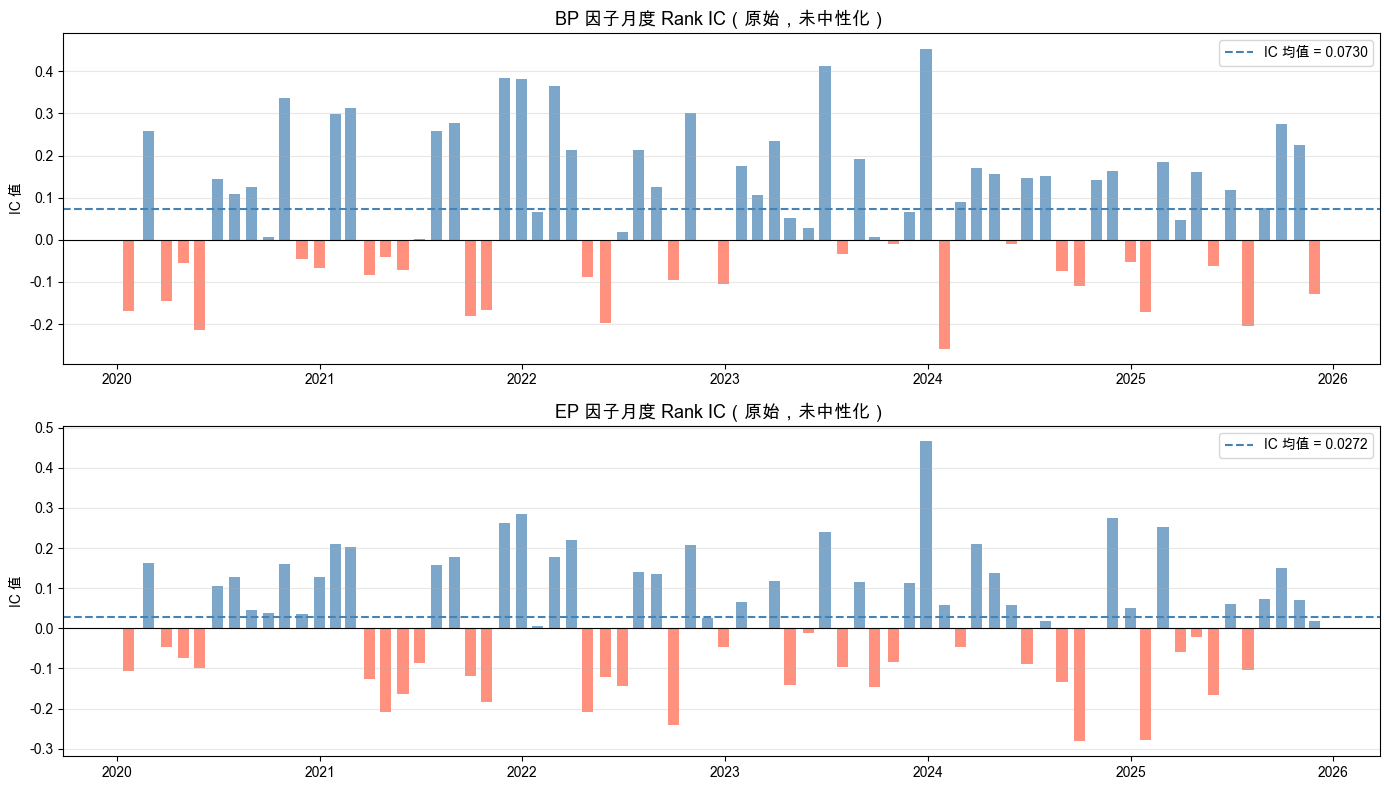

图表已保存到 data/ic_timeseries.png ✓


In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 上图：BP 原始因子 IC（有效的那个）
axes[0].bar(ic_df.index, ic_df['IC_BP_raw'],
            color=['steelblue' if x > 0 else 'tomato' for x in ic_df['IC_BP_raw']],
            alpha=0.7, width=20)
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].axhline(y=ic_df['IC_BP_raw'].mean(), color='steelblue',
                linewidth=1.5, linestyle='--',
                label=f'IC 均值 = {ic_df["IC_BP_raw"].mean():.4f}')
axes[0].set_title('BP 因子月度 Rank IC（原始，未中性化）', fontsize=13)
axes[0].set_ylabel('IC 值')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 下图：EP 原始因子 IC（对比）
axes[1].bar(ic_df.index, ic_df['IC_EP_raw'],
            color=['steelblue' if x > 0 else 'tomato' for x in ic_df['IC_EP_raw']],
            alpha=0.7, width=20)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].axhline(y=ic_df['IC_EP_raw'].mean(), color='steelblue',
                linewidth=1.5, linestyle='--',
                label=f'IC 均值 = {ic_df["IC_EP_raw"].mean():.4f}')
axes[1].set_title('EP 因子月度 Rank IC（原始，未中性化）', fontsize=13)
axes[1].set_ylabel('IC 值')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/ic_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存到 data/ic_timeseries.png ✓')

In [47]:
# 修复分组逻辑
# assign_quintile 不用 include_groups，改用显式列选择

def assign_quintile(series):
    """
    直接传入因子值的 Series，而不是整个 group
    这样完全避免 include_groups 的问题
    """
    result = series.copy() * np.nan
    valid_idx = series.dropna().index

    if len(valid_idx) < 50:
        return result

    result.loc[valid_idx] = pd.qcut(
        series.loc[valid_idx],
        q=5,
        labels=[1, 2, 3, 4, 5],
        duplicates='drop'
    ).astype(float)

    return result

# 直接对因子列做 groupby，不传整个 df
df['BP_quintile'] = (
    df.groupby('trade_date')['BP']
    .transform(lambda x: assign_quintile(x))
)

df['EP_quintile'] = (
    df.groupby('trade_date')['EP']
    .transform(lambda x: assign_quintile(x))
)

# 计算每组每月平均收益
bp_quintile_returns = (
    df.groupby(['trade_date', 'BP_quintile'])['forward_return'].mean()
)
ep_quintile_returns = (
    df.groupby(['trade_date', 'EP_quintile'])['forward_return'].mean()
)

bp_mean = bp_quintile_returns.groupby('BP_quintile').mean()
ep_mean = ep_quintile_returns.groupby('EP_quintile').mean()

print('BP 原始因子各组平均月度收益率：')
for q, r in bp_mean.items():
    print(f'  Q{int(q)}：{r:.2%}')

print()
print('EP 原始因子各组平均月度收益率：')
for q, r in ep_mean.items():
    print(f'  Q{int(q)}：{r:.2%}')

BP 原始因子各组平均月度收益率：
  Q1：0.11%
  Q2：0.81%
  Q3：1.18%
  Q4：1.45%
  Q5：1.46%

EP 原始因子各组平均月度收益率：
  Q1：1.15%
  Q2：0.85%
  Q3：1.02%
  Q4：1.17%
  Q5：0.84%


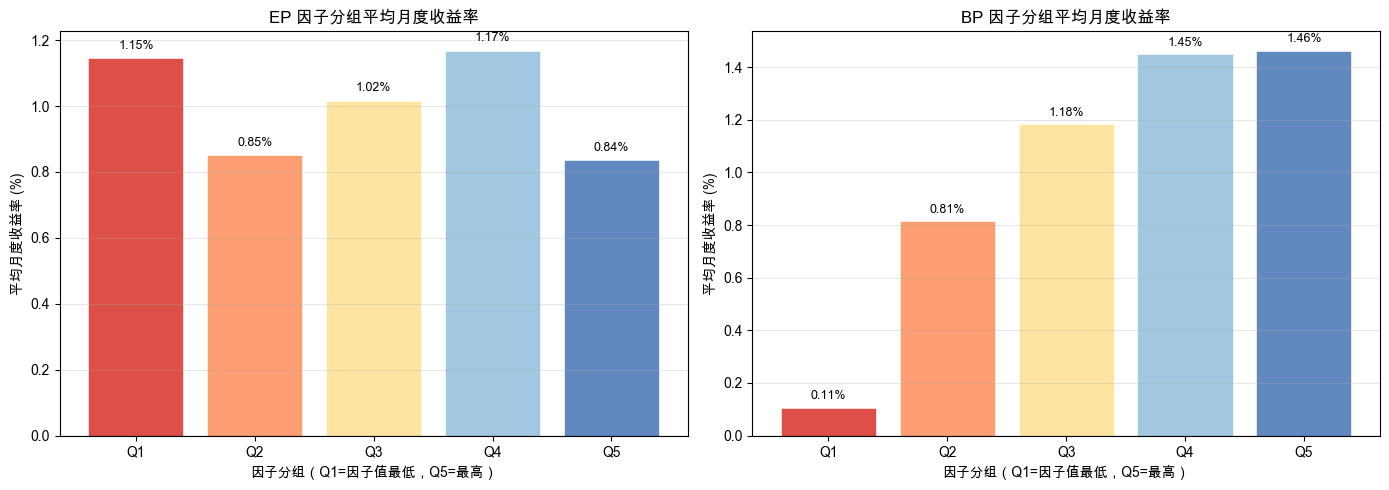

图表已保存到 data/quintile_returns.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EP 因子分组
bars1 = axes[0].bar(
    [f'Q{int(q)}' for q in ep_mean.index],
    ep_mean.values * 100,  # 转成百分比
    color=['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4'],
    alpha=0.85, edgecolor='white', linewidth=0.5
)
axes[0].set_title('EP 因子分组平均月度收益率', fontsize=12)
axes[0].set_ylabel('平均月度收益率 (%)')
axes[0].set_xlabel('因子分组（Q1=因子值最低，Q5=最高）')
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].grid(axis='y', alpha=0.3)

# 在柱子上方显示数值
for bar, val in zip(bars1, ep_mean.values * 100):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

# BP 因子分组
bars2 = axes[1].bar(
    [f'Q{int(q)}' for q in bp_mean.index],
    bp_mean.values * 100,
    color=['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4'],
    alpha=0.85, edgecolor='white', linewidth=0.5
)
axes[1].set_title('BP 因子分组平均月度收益率', fontsize=12)
axes[1].set_ylabel('平均月度收益率 (%)')
axes[1].set_xlabel('因子分组（Q1=因子值最低，Q5=最高）')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, bp_mean.values * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data/quintile_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存到 data/quintile_returns.png')

In [49]:
# 多空组合：买 Q5 卖 Q1
bp_pivot = bp_quintile_returns.unstack('BP_quintile')
ep_pivot = ep_quintile_returns.unstack('EP_quintile')

bp_ls = bp_pivot[5.0] - bp_pivot[1.0]
ep_ls = ep_pivot[5.0] - ep_pivot[1.0]

# 注意：forward_3m 是3个月收益，但我们每月换仓
# 所以净值曲线用月度多空收益来累乘（会有重叠，但方向是对的）
bp_nav = (1 + bp_ls).cumprod()
ep_nav = (1 + ep_ls).cumprod()

market_return = df.groupby('trade_date')['forward_return'].mean()
market_nav = (1 + market_return).cumprod()

def calc_performance(returns):
    annual_return = returns.mean() * 12
    annual_vol = returns.std() * np.sqrt(12)
    sharpe = annual_return / annual_vol
    nav = (1 + returns).cumprod()
    rolling_max = nav.cummax()
    drawdown = (nav - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    return annual_return, annual_vol, sharpe, max_drawdown

bp_stats = calc_performance(bp_ls.dropna())
ep_stats = calc_performance(ep_ls.dropna())

print('=' * 55)
print(f'{"指标":<15} {"BP 多空组合":>15} {"EP 多空组合":>15}')
print('=' * 55)
print(f'{"年化收益率":<15} {bp_stats[0]:>14.2%} {ep_stats[0]:>14.2%}')
print(f'{"年化波动率":<15} {bp_stats[1]:>14.2%} {ep_stats[1]:>14.2%}')
print(f'{"夏普比率":<15} {bp_stats[2]:>14.4f} {ep_stats[2]:>14.4f}')
print(f'{"最大回撤":<15} {bp_stats[3]:>14.2%} {ep_stats[3]:>14.2%}')
print('=' * 55)

指标                      BP 多空组合         EP 多空组合
年化收益率                   16.28%         -3.72%
年化波动率                   17.92%         16.59%
夏普比率                    0.9086        -0.2243
最大回撤                   -13.25%        -33.93%


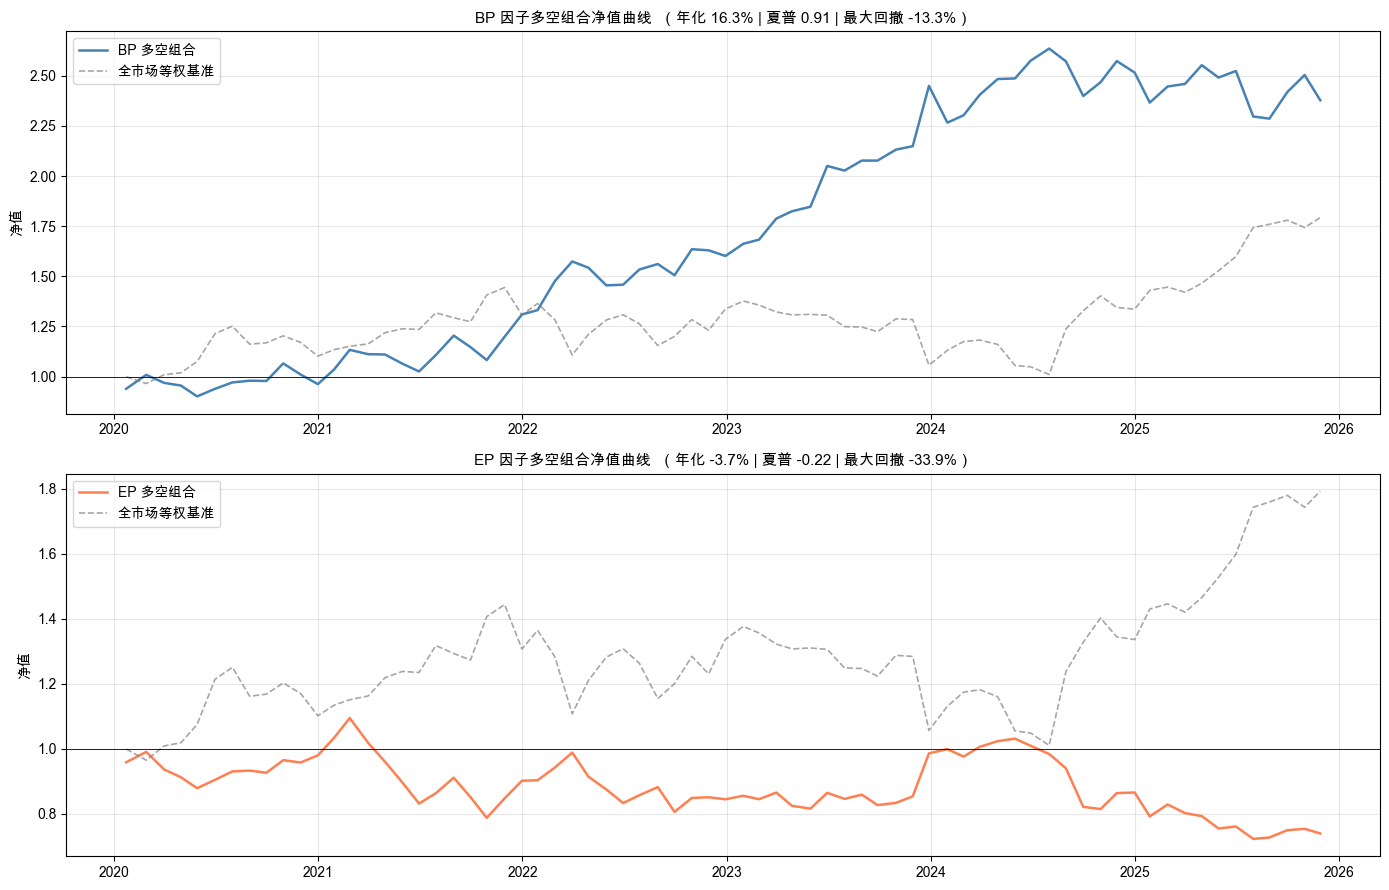

图表已保存 ✓


In [50]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

bp_pivot = bp_quintile_returns.unstack('BP_quintile')
ep_pivot = ep_quintile_returns.unstack('EP_quintile')
bp_ls = bp_pivot[5.0] - bp_pivot[1.0]
ep_ls = ep_pivot[5.0] - ep_pivot[1.0]
bp_nav = (1 + bp_ls).cumprod()
ep_nav = (1 + ep_ls).cumprod()
market_return = df.groupby('trade_date')['forward_return'].mean()
market_nav = (1 + market_return).cumprod()

def calc_performance(returns):
    annual_return = returns.mean() * 12
    annual_vol = returns.std() * np.sqrt(12)
    sharpe = annual_return / annual_vol
    nav = (1 + returns).cumprod()
    rolling_max = nav.cummax()
    drawdown = (nav - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    return annual_return, annual_vol, sharpe, max_drawdown

bp_stats = calc_performance(bp_ls.dropna())
ep_stats = calc_performance(ep_ls.dropna())

# BP 净值曲线
axes[0].plot(bp_nav.index, bp_nav.values,
             color='steelblue', linewidth=1.8, label='BP 多空组合')
axes[0].plot(market_nav.index, market_nav.values,
             color='gray', linewidth=1.2, linestyle='--',
             alpha=0.7, label='全市场等权基准')
axes[0].axhline(y=1, color='black', linewidth=0.6)
axes[0].set_title(
    f'BP 因子多空组合净值曲线  '
    f'（年化 {bp_stats[0]:.1%} | 夏普 {bp_stats[2]:.2f} | 最大回撤 {bp_stats[3]:.1%}）',
    fontsize=11)
axes[0].set_ylabel('净值')
axes[0].legend()
axes[0].grid(alpha=0.3)

# EP 净值曲线
axes[1].plot(ep_nav.index, ep_nav.values,
             color='coral', linewidth=1.8, label='EP 多空组合')
axes[1].plot(market_nav.index, market_nav.values,
             color='gray', linewidth=1.2, linestyle='--',
             alpha=0.7, label='全市场等权基准')
axes[1].axhline(y=1, color='black', linewidth=0.6)
axes[1].set_title(
    f'EP 因子多空组合净值曲线  '
    f'（年化 {ep_stats[0]:.1%} | 夏普 {ep_stats[2]:.2f} | 最大回撤 {ep_stats[3]:.1%}）',
    fontsize=11)
axes[1].set_ylabel('净值')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/nav_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存 ✓')

In [51]:
summary = pd.DataFrame({
    '指标': ['IC均值', 'IC标准差', 'ICIR', 'IC>0比例',
             '年化收益率', '年化波动率', '夏普比率', '最大回撤'],
    'EP因子': [
        ic_df['IC_EP_raw'].mean(),
        ic_df['IC_EP_raw'].std(),
        ic_df['IC_EP_raw'].mean() / ic_df['IC_EP_raw'].std(),
        (ic_df['IC_EP_raw'] > 0).mean(),
        ep_stats[0], ep_stats[1], ep_stats[2], ep_stats[3]
    ],
    'BP因子': [
        ic_df['IC_BP_raw'].mean(),
        ic_df['IC_BP_raw'].std(),
        ic_df['IC_BP_raw'].mean() / ic_df['IC_BP_raw'].std(),
        (ic_df['IC_BP_raw'] > 0).mean(),
        bp_stats[0], bp_stats[1], bp_stats[2], bp_stats[3]
    ]
})

summary.to_csv('data/results_summary.csv', index=False)
print('结果汇总已保存到 data/results_summary.csv')
print()
print(summary.to_string(index=False))

结果汇总已保存到 data/results_summary.csv

    指标      EP因子      BP因子
  IC均值  0.027193  0.072961
 IC标准差  0.154300  0.173998
  ICIR  0.176233  0.419320
IC>0比例  0.577465  0.619718
 年化收益率 -0.037208  0.162794
 年化波动率  0.165895  0.179163
  夏普比率 -0.224289  0.908635
  最大回撤 -0.339335 -0.132522
